In [13]:
# Import Libraries

! pip install opencv-python
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [5]:
# Define Dataset Path

dataset_path = 'C:\\shivangee\\Module-5\\Module5_2511562_Part2cnn-computer-vision-part-2-cnn-computer-vision\\part_2_cnn_computer_vision\\images'

In [7]:
# ============================================================
# TASK 1- Problem Identification
# ============================================================

## Problem Type: Image Classification

# The dataset is an image classification problem because each image belongs to one defect category.

In [8]:
# ============================================================
# TASK 2 - Dataset Exploration
# ============================================================

# Class Names

classes = ['normal', 'scratch', 'dent', 'stain']

classes

['normal', 'scratch', 'dent', 'stain']

In [9]:
# Count Images Per Class

for cls in classes:
    path = os.path.join(dataset_path, cls)
    print(cls, ":", len(os.listdir(path)))

normal : 120
scratch : 120
dent : 120
stain : 120


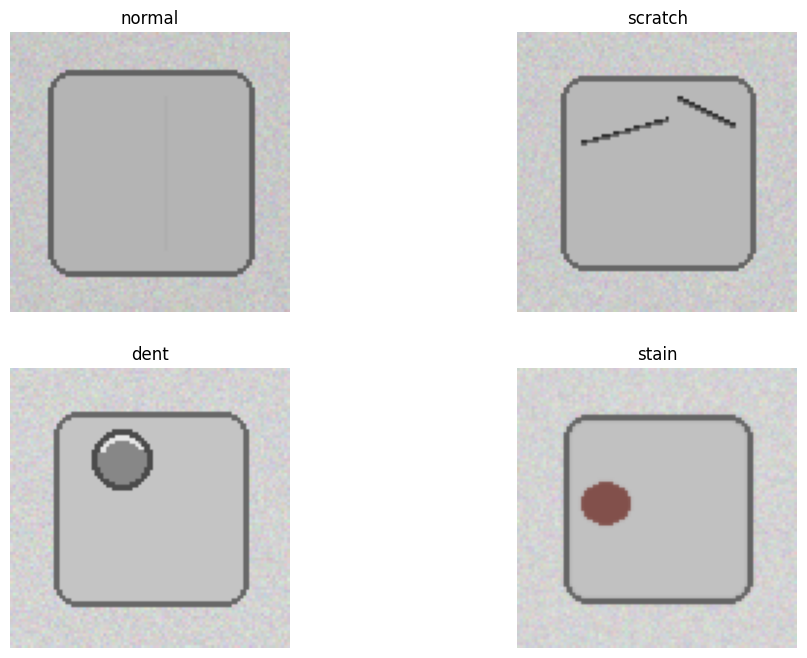

In [14]:
# Display Sample Images

plt.figure(figsize=(12,8))

for i, cls in enumerate(classes):
    
    path = os.path.join(dataset_path, cls)
    img_name = os.listdir(path)[0]
    
    img_path = os.path.join(path, img_name)
    
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    plt.subplot(2,2,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis('off')

plt.show()

In [15]:
# Check Image Dimensions

sample_path = os.path.join(dataset_path, classes[0])

sample_img = cv2.imread(
    os.path.join(sample_path, os.listdir(sample_path)[0])
)

print("Image Shape:", sample_img.shape)

Image Shape: (96, 96, 3)


In [16]:
# ============================================================
# TASK 3- image preprocessing
# ============================================================

# Image Parameters

IMG_SIZE = 128

X = []
y = []

In [17]:
# Load Images

for label, cls in enumerate(classes):
    
    path = os.path.join(dataset_path, cls)
    
    for img_name in os.listdir(path):
        
        img_path = os.path.join(path, img_name)
        
        img = cv2.imread(img_path)
        
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        
        img = img / 255.0
        
        X.append(img)
        y.append(label)

In [18]:
# Convert to Arrays

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(480, 128, 128, 3)
(480,)


In [19]:
# Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [20]:
# Convert Labels to Categorical

y_train = to_categorical(y_train, num_classes=4)
y_test = to_categorical(y_test, num_classes=4)

In [22]:
# Data Augmentation

datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

datagen.fit(X_train)

In [23]:
# ============================================================
# TASK 4 - CNN Model Creation
# ============================================================

# Build CNN Model

model = Sequential()

model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(128,128,3)
    )
)

model.add(MaxPooling2D((2,2)))

model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)

model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))

model.add(Dropout(0.5))

model.add(Dense(4, activation='softmax'))

c:\Users\kushs\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [24]:
# Compile Model

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [25]:
# Model Summary

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,392,836 (28.20 MB)

 Trainable params: 7,392,836 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

In [26]:
# ============================================================
# TASK 5 - Model Training an evaluation
# ============================================================

# Train Model

history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=15,
    validation_data=(X_test, y_test)
)


Epoch 1/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 291ms/step - accuracy: 0.2552 - loss: 2.2302 - val_accuracy: 0.3958 - val_loss: 1.3712
Epoch 2/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 218ms/step - accuracy: 0.2891 - loss: 1.3531 - val_accuracy: 0.3646 - val_loss: 1.3137
Epoch 3/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 223ms/step - accuracy: 0.4297 - loss: 1.2323 - val_accuracy: 0.4688 - val_loss: 1.0755
Epoch 4/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 230ms/step - accuracy: 0.5339 - loss: 1.0440 - val_accuracy: 0.7396 - val_loss: 0.9107
Epoch 5/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 231ms/step - accuracy: 0.5755 - loss: 0.9018 - val_accuracy: 0.8125 - val_loss: 0.7749
Epoch 6/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 281ms/step - accuracy: 0.6536 - loss: 0.8015 - val_accuracy: 0.8229 - val_loss: 0.6554
Epoch 7/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 238ms/step - accuracy: 0.6875 - loss: 0.7404 - val_accuracy: 0.7604 - val_loss: 0.6478
Epoch 8/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 283ms/step - accuracy: 0.7057 - loss: 0.6924 - val_accuracy: 0.

In [27]:
# Evaluate Model

loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.9271 - loss: 0.3796
Test Accuracy: 0.9270833134651184


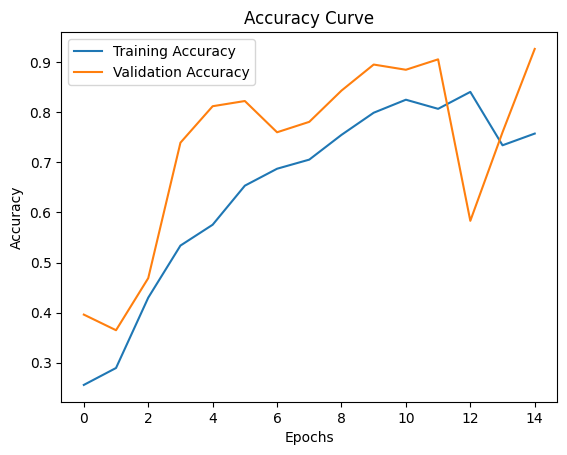

In [28]:
# Accuracy Graph

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend()

plt.show()

OSError: [Errno 22] Invalid argument: 'C:\\shivangee\\Module-5\\Module5_2511562_Part2cnn-computer-vision-part-2-cnn-computer-vision\\results\x07ccuracy_loss_curves.png'

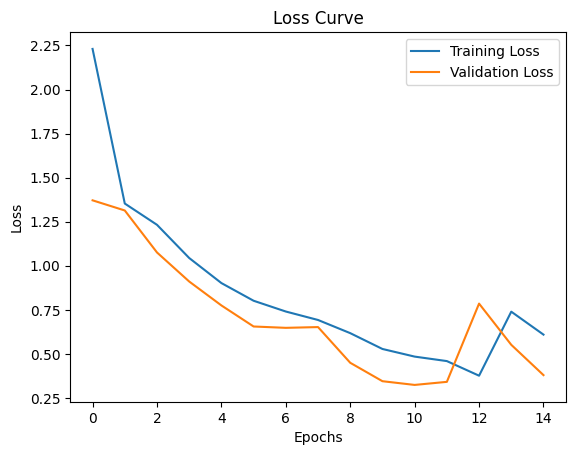

In [ ]:
# Loss Graph

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()
plt.savefig(
    r'C:\shivangee\Module-5\Module5_2511562_Part2cnn-computer-vision-part-2-cnn-computer-vision\results\accuracy_loss_curves.png',
    bbox_inches='tight'
)

plt.show()

In [31]:
# Loss Graph

# Predictions

y_pred = model.predict(X_test)

y_pred_classes = np.argmax(y_pred, axis=1)

y_true = np.argmax(y_test, axis=1)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


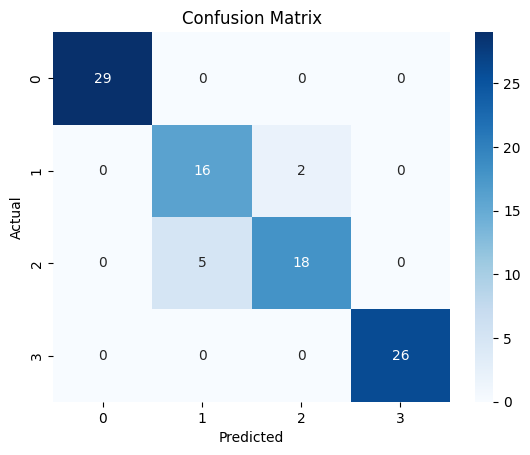

In [36]:
# Confusion Matrix

cm = confusion_matrix(y_true, y_pred_classes)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig(
    'C:\\shivangee\\Module-5\\Module5_2511562_Part2cnn-computer-vision-part-2-cnn-computer-vision\\results\\confusion_matrix.png',
    bbox_inches='tight'
)

plt.show()

In [33]:
# Classification Report

print(classification_report(y_true, y_pred_classes))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        29
           1       0.76      0.89      0.82        18
           2       0.90      0.78      0.84        23
           3       1.00      1.00      1.00        26

    accuracy                           0.93        96
   macro avg       0.92      0.92      0.91        96
weighted avg       0.93      0.93      0.93        96



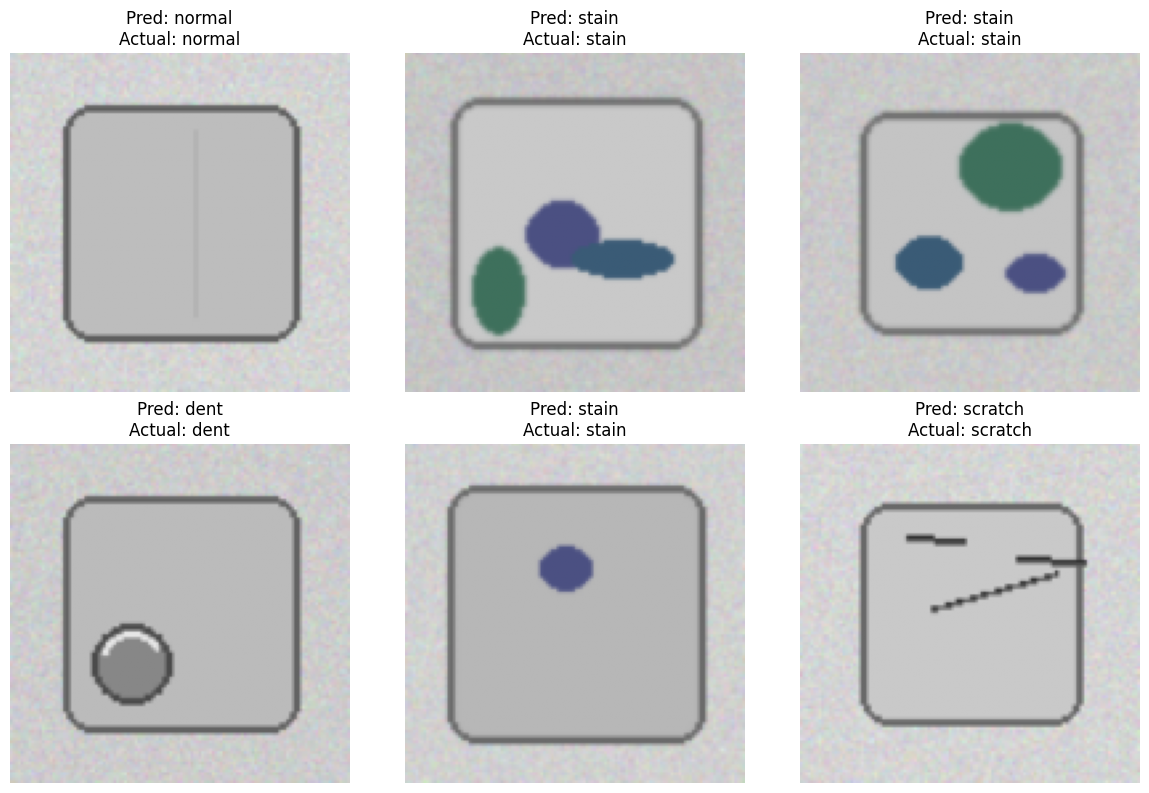

In [35]:
# Sample Predictions

plt.figure(figsize=(12,8))

for i in range(6):
    
    plt.subplot(2,3,i+1)
    
    plt.imshow(X_test[i])
    
    pred = classes[y_pred_classes[i]]
    actual = classes[y_true[i]]
    
    plt.title(f"Pred: {pred}\nActual: {actual}")
    
    plt.axis('off')

plt.tight_layout()
plt.savefig(
    'C:\\shivangee\\Module-5\\Module5_2511562_Part2cnn-computer-vision-part-2-cnn-computer-vision\\sample_predictions\\prediction_outputs.png',
    bbox_inches='tight'
)
plt.show()